In [ ]:
import pandas as pd
import numpy as np
from google.colab import files

# Upload and read the CSV
uploaded = files.upload()
df = pd.read_csv('pokemon_competitive_analysis.csv')

# Clean the data - replace 'NoUsage' and 'No_type' with NaN
df = df.replace(['NoUsage', 'No_type'], np.nan)

# Convert usage columns to numeric
usage_cols = ['Smogon_VGC_Usage_2022', 'Smogon_VGC_Usage_2023',
              'Smogon_VGC_Usage_2024', 'Worlds_VGC_Usage_2022',
              'Worlds_VGC_Usage_2023', 'Worlds_VGC_Usage_2024']

for col in usage_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill NaN with 0 for aggregation
df[usage_cols] = df[usage_cols].fillna(0)

Saving pokemon_competitive_analysis.csv to pokemon_competitive_analysis (4).csv


In [ ]:
# Group by primary type and sum usage for each year
type_usage = df.groupby('type1')[usage_cols].sum().round(2)

# Sort by 2024 usage (descending)
type_usage_sorted_2024 = type_usage.sort_values('Smogon_VGC_Usage_2024', ascending=False)

print("=== Most Used Primary Types in 2024 (Smogon) ===\n")
print(type_usage_sorted_2024[['Smogon_VGC_Usage_2024']].head(10))
print("\n")

# Show trend across years for top types
print("=== Top 5 Types Usage Trends (2022-2024) ===\n")
top_5_types = type_usage_sorted_2024.head(5).index
trend_data = type_usage.loc[top_5_types, ['Smogon_VGC_Usage_2022', 'Smogon_VGC_Usage_2023', 'Smogon_VGC_Usage_2024']]
print(trend_data)

=== Most Used Primary Types in 2024 (Smogon) ===

          Smogon_VGC_Usage_2024
type1                          
grass                    102.84
fighting                  71.97
fire                      69.34
psychic                   67.11
ghost                     61.02
ground                    48.36
dark                      47.96
water                     46.19
electric                  35.88
dragon                    34.31


=== Top 5 Types Usage Trends (2022-2024) ===

          Smogon_VGC_Usage_2022  Smogon_VGC_Usage_2023  Smogon_VGC_Usage_2024
type1                                                                        
grass                     82.32                 126.01                 102.84
fighting                  15.97                 120.98                  71.97
fire                      73.76                 114.00                  69.34
psychic                   50.94                  51.51                  67.11
ghost                     14.35                  5

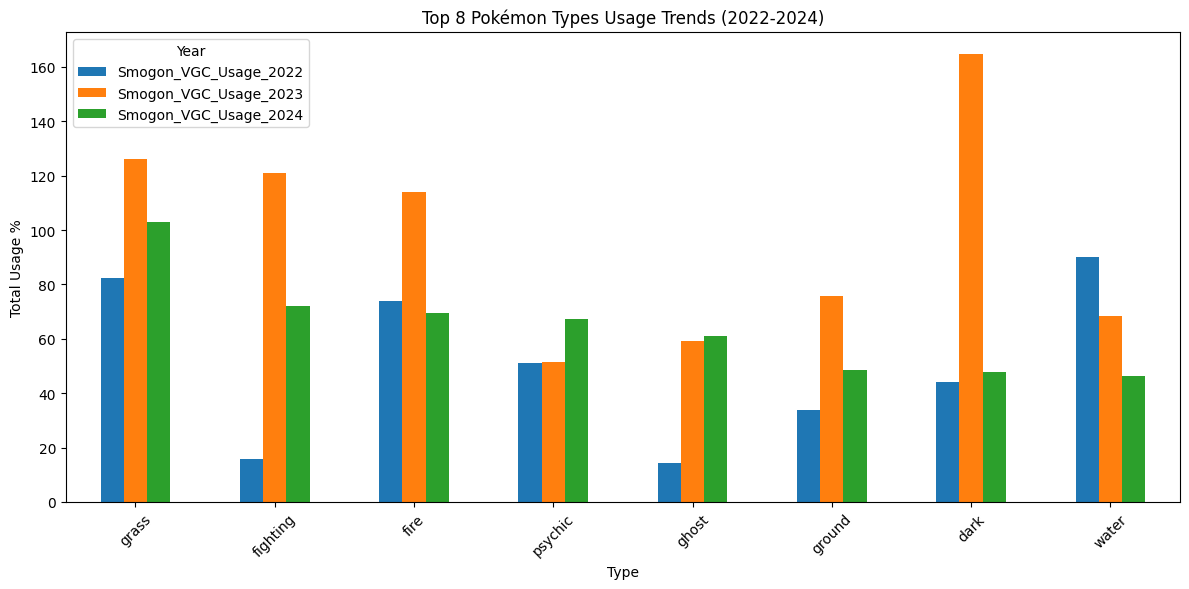

In [ ]:
import matplotlib.pyplot as plt

# Prepare data for top 8 types in 2024
top_8 = type_usage_sorted_2024.head(8)
top_8_types = top_8.index.tolist()

# Create comparison dataframe
comparison = type_usage.loc[top_8_types, ['Smogon_VGC_Usage_2022', 'Smogon_VGC_Usage_2023', 'Smogon_VGC_Usage_2024']]

# Plot
comparison.plot(kind='bar', figsize=(12, 6))
plt.title('Top 8 Pokémon Types Usage Trends (2022-2024)')
plt.xlabel('Type')
plt.ylabel('Total Usage %')
plt.legend(title='Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

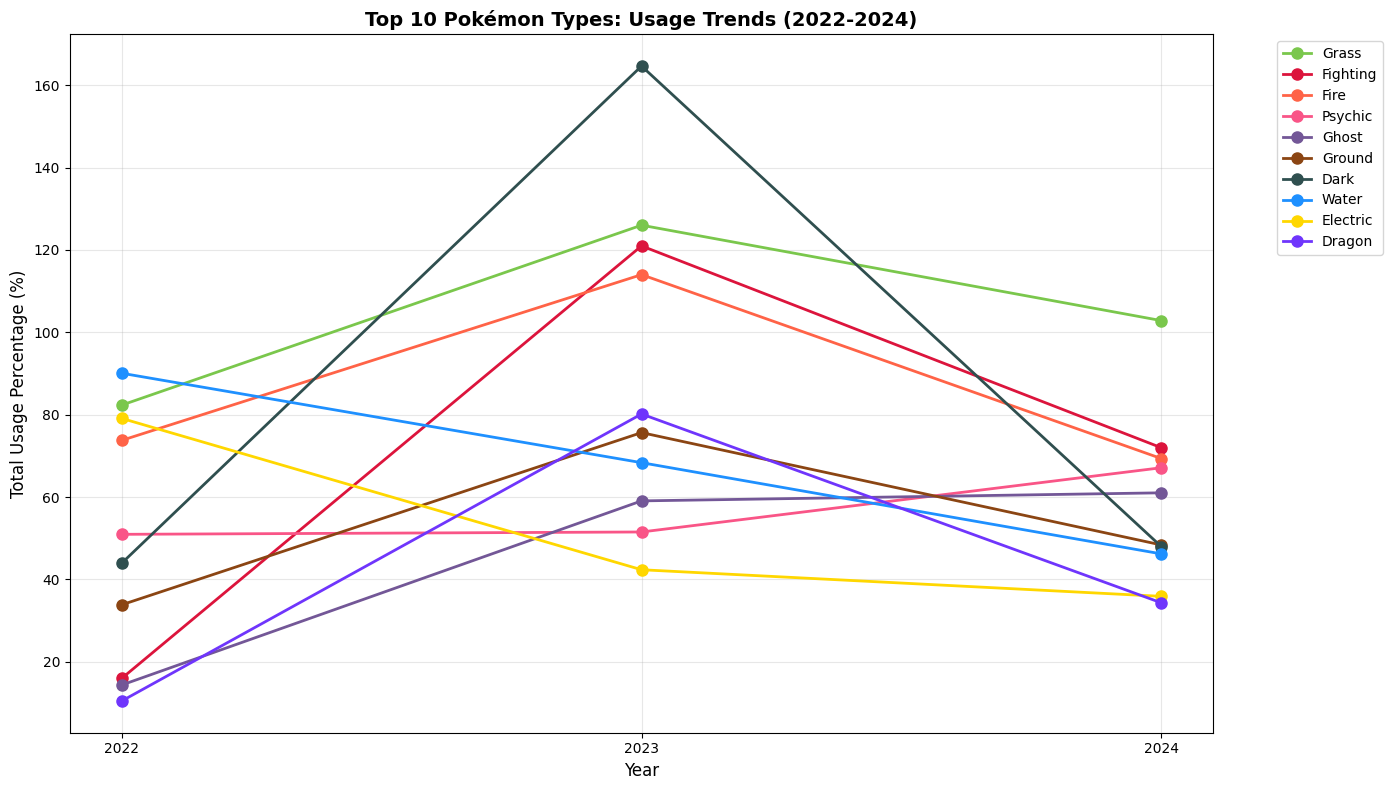

In [ ]:
# Sort by 2024 usage to get top types
top_types = type_usage.sort_values('Smogon_VGC_Usage_2024', ascending=False).head(10)

# Define custom colors for each type
custom_colors = {
    'steel': '#2E86AB',      # Grey
    'grass': '#7AC74C',      #Green
    'fairy': '#FF69B4',      # Pink
    'psychic': '#F95587',    #Magenta
    'ghost': '#735797',      # Purple
    'water': '#1E90FF',      # Dodger Blue
    'ground': '#8B4513',     # Brown
    'dark': '#2F4F4F',       # Dark Slate Gray
    'dragon': '#6F35FC',     # Indigo
    'fighting': '#DC143C',   # Crimson
    'electric': '#FFD700',   # Gold
    'fire': '#FF6347'        # Tomato
}

# Create line plot with custom colors
plt.figure(figsize=(14, 8))

years = ['2022', '2023', '2024']
for type_name in top_types.index[:10]:
    usage_values = [top_types.loc[type_name, 'Smogon_VGC_Usage_2022'],
                    top_types.loc[type_name, 'Smogon_VGC_Usage_2023'],
                    top_types.loc[type_name, 'Smogon_VGC_Usage_2024']]

    # Use custom color if available, otherwise use default
    color = custom_colors.get(type_name, 'gray')

    plt.plot(years, usage_values, marker='o', linewidth=2,
             label=type_name.capitalize(), color=color, markersize=8)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Usage Percentage (%)', fontsize=12)
plt.title('Top 10 Pokémon Types: Usage Trends (2022-2024)', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Check the generation column
print("Generation column sample:")
print(df[['name', 'generation']].head(20))
print("\nUnique generations in dataset:")
print(df['generation'].unique())

Generation column sample:
                name    generation
0          bulbasaur  generation-i
1            ivysaur  generation-i
2           venusaur  generation-i
3      venusaur-mega  generation-i
4      venusaur-gmax  generation-i
5         charmander  generation-i
6         charmeleon  generation-i
7          charizard  generation-i
8   charizard-mega-x  generation-i
9   charizard-mega-y  generation-i
10    charizard-gmax  generation-i
11          squirtle  generation-i
12         wartortle  generation-i
13         blastoise  generation-i
14    blastoise-mega  generation-i
15    blastoise-gmax  generation-i
16          caterpie  generation-i
17           metapod  generation-i
18        butterfree  generation-i
19   butterfree-gmax  generation-i

Unique generations in dataset:
['generation-i' 'generation-ii' 'generation-iii' 'generation-iv'
 'generation-v' 'generation-vi' 'generation-vii' 'generation-viii'
 'generation-ix']


In [ ]:
# Clean the data
df = df.replace(['NoUsage', 'No_type'], np.nan)

# Convert usage columns to numeric
usage_cols = ['Smogon_VGC_Usage_2022', 'Smogon_VGC_Usage_2023',
              'Smogon_VGC_Usage_2024', 'Worlds_VGC_Usage_2022',
              'Worlds_VGC_Usage_2023', 'Worlds_VGC_Usage_2024']

for col in usage_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[usage_cols] = df[usage_cols].fillna(0)

# Group by generation and sum usage
gen_usage = df.groupby('generation')[['Smogon_VGC_Usage_2022',
                                       'Smogon_VGC_Usage_2023',
                                       'Smogon_VGC_Usage_2024']].sum().round(2)

print("=== Usage by Generation (Smogon VGC) ===\n")
print(gen_usage.sort_values('Smogon_VGC_Usage_2024', ascending=False))

=== Usage by Generation (Smogon VGC) ===

                 Smogon_VGC_Usage_2022  Smogon_VGC_Usage_2023  \
generation                                                      
generation-ix                     0.00                 544.31   
generation-viii                 202.90                 186.44   
generation-v                    107.74                 126.17   
generation-vii                   92.00                  14.86   
generation-iii                   77.47                  34.21   
generation-i                     58.63                  75.26   
generation-iv                    37.33                  86.45   
generation-ii                    15.80                  22.62   
generation-vi                    16.74                  31.76   

                 Smogon_VGC_Usage_2024  
generation                              
generation-ix                   308.23  
generation-viii                 164.14  
generation-v                     80.29  
generation-vii                   48.6

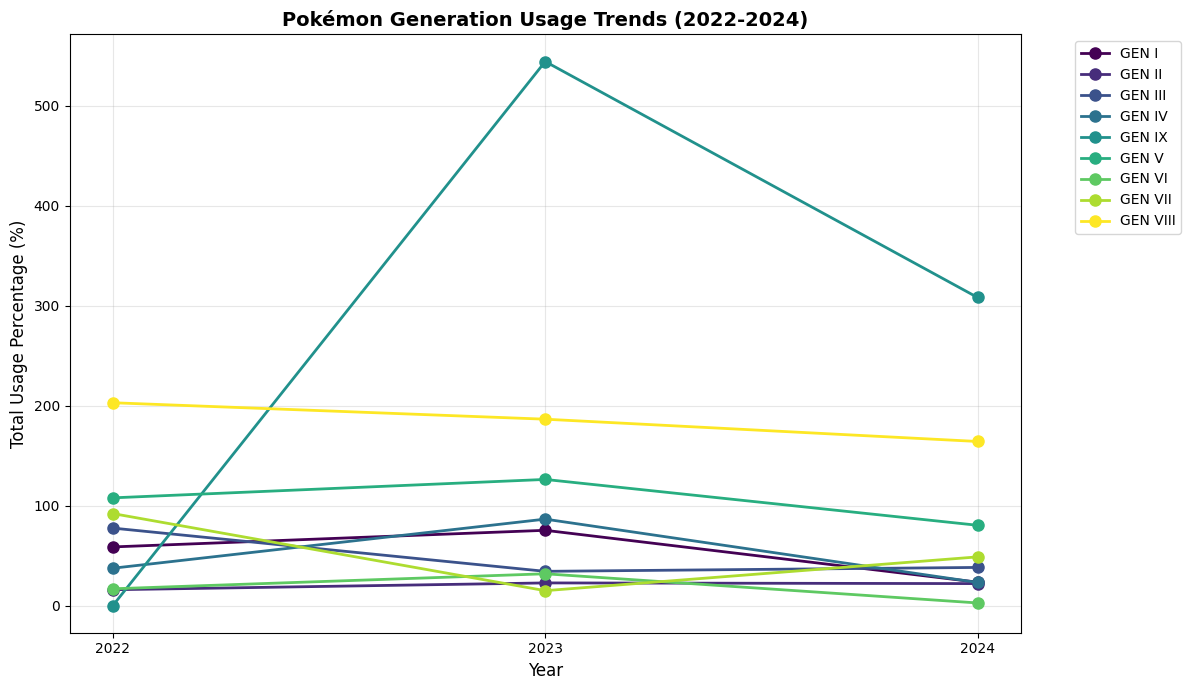

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare generation data for plotting
gen_trend = df.groupby('generation')[['Smogon_VGC_Usage_2022',
                                       'Smogon_VGC_Usage_2023',
                                       'Smogon_VGC_Usage_2024']].sum()

# Remove generations with very low usage
gen_trend = gen_trend[gen_trend['Smogon_VGC_Usage_2024'] > 1]

# Plot generation trends
plt.figure(figsize=(12, 7))
years = ['2022', '2023', '2024']

# Color generations by era
colors = plt.cm.viridis(np.linspace(0, 1, len(gen_trend)))

for i, gen in enumerate(gen_trend.index):
    values = [gen_trend.loc[gen, 'Smogon_VGC_Usage_2022'],
              gen_trend.loc[gen, 'Smogon_VGC_Usage_2023'],
              gen_trend.loc[gen, 'Smogon_VGC_Usage_2024']]

    # Clean up generation label for display
    gen_label = gen.replace('generation-', 'Gen ').upper()

    plt.plot(years, values, marker='o', linewidth=2,
             label=gen_label, color=colors[i], markersize=8)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Usage Percentage (%)', fontsize=12)
plt.title('Pokémon Generation Usage Trends (2022-2024)', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Saving pokemon_competitive_analysis.csv to pokemon_competitive_analysis.csv
Gen IX Usage:
2022: 0.0%
2023: 544.3%
2024: 308.2%

Trend: +154.12% per year


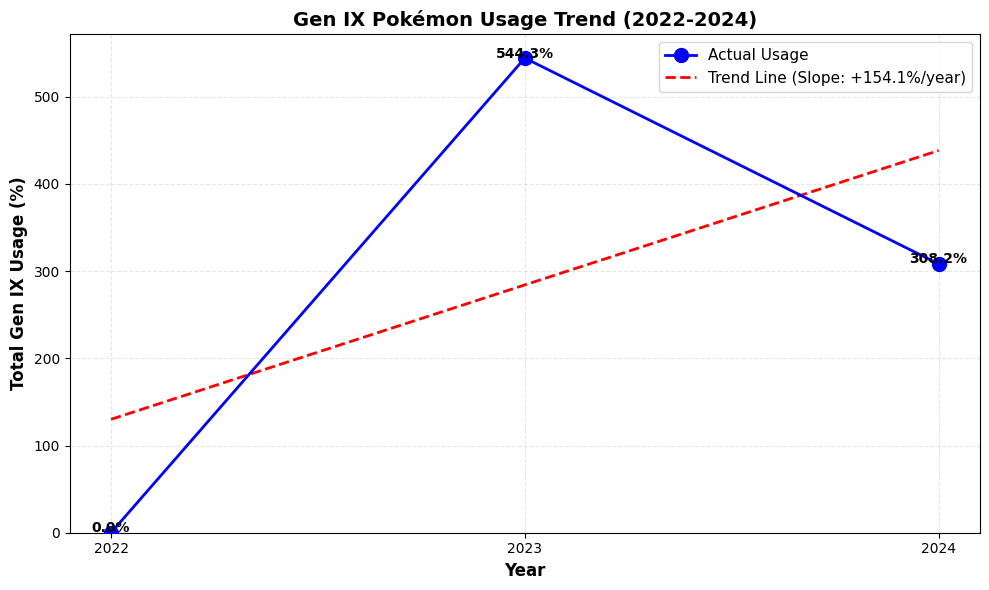

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload and read the CSV
uploaded = files.upload()
df = pd.read_csv('pokemon_competitive_analysis.csv')

# Clean the data
df = df.replace(['NoUsage', 'No_type'], np.nan)

# Convert usage columns to numbers
df['Smogon_VGC_Usage_2022'] = pd.to_numeric(df['Smogon_VGC_Usage_2022'], errors='coerce')
df['Smogon_VGC_Usage_2023'] = pd.to_numeric(df['Smogon_VGC_Usage_2023'], errors='coerce')
df['Smogon_VGC_Usage_2024'] = pd.to_numeric(df['Smogon_VGC_Usage_2024'], errors='coerce')

# Fill empty values with 0
df[['Smogon_VGC_Usage_2022', 'Smogon_VGC_Usage_2023', 'Smogon_VGC_Usage_2024']] = df[['Smogon_VGC_Usage_2022', 'Smogon_VGC_Usage_2023', 'Smogon_VGC_Usage_2024']].fillna(0)

# Get only Gen IX Pokémon
gen9 = df[df['generation'] == 'generation-ix']

# Calculate total Gen IX usage each year
usage_2022 = gen9['Smogon_VGC_Usage_2022'].sum()
usage_2023 = gen9['Smogon_VGC_Usage_2023'].sum()
usage_2024 = gen9['Smogon_VGC_Usage_2024'].sum()

print(f"Gen IX Usage:")
print(f"2022: {usage_2022:.1f}%")
print(f"2023: {usage_2023:.1f}%")
print(f"2024: {usage_2024:.1f}%")

# Simple linear regression using formulas
years = [2022, 2023, 2024]
usages = [usage_2022, usage_2023, usage_2024]

# Calculate means
mean_x = sum(years) / len(years)
mean_y = sum(usages) / len(usages)

# Calculate slope (trend)
numerator = sum((years[i] - mean_x) * (usages[i] - mean_y) for i in range(len(years)))
denominator = sum((years[i] - mean_x) ** 2 for i in range(len(years)))
slope = numerator / denominator

# Calculate intercept
intercept = mean_y - slope * mean_x

print(f"\nTrend: {slope:+.2f}% per year")

# Create the graph
plt.figure(figsize=(10, 6))

# Plot actual data points (blue dots with line)
plt.plot(years, usages, 'bo-', linewidth=2, markersize=10, label='Actual Usage', zorder=3)

# Plot trend line (only for 2022-2024)
trend_years = [2022, 2023, 2024]
trend_values = [slope * year + intercept for year in trend_years]
plt.plot(trend_years, trend_values, 'r--', linewidth=2, label=f'Trend Line (Slope: {slope:+.1f}%/year)', zorder=2)

# Add value labels on the points
plt.text(2022, usage_2022 + 0.5, f'{usage_2022:.1f}%', ha='center', fontsize=10, fontweight='bold')
plt.text(2023, usage_2023 + 0.5, f'{usage_2023:.1f}%', ha='center', fontsize=10, fontweight='bold')
plt.text(2024, usage_2024 + 0.5, f'{usage_2024:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Customize the graph
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Total Gen IX Usage (%)', fontsize=12, fontweight='bold')
plt.title('Gen IX Pokémon Usage Trend (2022-2024)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks([2022, 2023, 2024])
plt.ylim(bottom=0)  # Start y-axis at 0


plt.tight_layout()
plt.show()

